In [1]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import statsmodels.api as sm
insurance_df = pd.read_csv(r"C:\BIT_Data_analyst\05_regressions\01_lesson\insurance.csv")

insurance_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
X = sm.add_constant(insurance_df["age"])
y = insurance_df["charges"]
 
model = sm.OLS(y, X).fit()
 
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.089
Method:                 Least Squares   F-statistic:                     131.2
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           4.89e-29
Time:                        14:31:46   Log-Likelihood:                -14415.
No. Observations:                1338   AIC:                         2.883e+04
Df Residuals:                    1336   BIC:                         2.884e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3165.8850    937.149      3.378      0.001    1327.440    5004.330
age          257.7226     22.502     11.453      0.000     213.579     301.866
==============================================================================
Omnibus:                      399.600   Durbin-Watson:                   2.033
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              864.239
Skew:                           1.733   Prob(JB):                    2.15e-188
Kurtosis:                       4.869   Cond. No.                         124.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [3]:
customer_ages = [18, 25, 35, 45, 55]
 
X_predict = sm.add_constant(pd.DataFrame({"age": customer_ages}))
 
X_predict

,const,age
0,1.0,18
1,1.0,25
2,1.0,35
3,1.0,45
4,1.0,55


In [6]:
predictions = model.predict(X_predict)
 
predictions.name = "predictions"

In [7]:
## Compare predictions to actual values
 
(insurance_df
 .query("age in @customer_ages")
 .groupby("age")
 .agg({"charges": "mean"})
 .reset_index()
 .merge(predictions, left_index=True, right_index=True)
 .assign(
     error = lambda x: x["predictions"] - x["charges"],
     pct_difference = lambda x: (x["error"] / x["charges"]) * 100
 
 )
)

,age,charges,predictions,error,pct_difference
0,18,7086.217556,7804.892142,718.674586,10.141865
1,25,9838.365311,9608.950473,-229.414838,-2.331839
2,35,11307.182031,12186.176659,878.994628,7.773773
3,45,14830.199856,14763.402846,-66.797010,-0.450412
4,55,16164.545488,17340.629033,1176.083544,7.275698


<Axes: ylabel='None'>

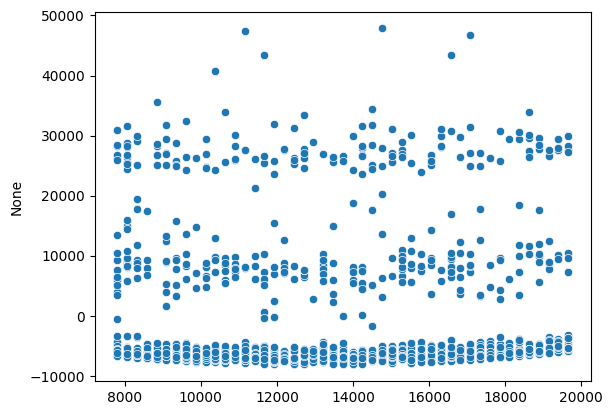

In [8]:
# Plot Residuals -- three tiers here to try to predict with new features
 
sns.scatterplot(x=model.predict(), y=model.resid)

In [9]:
features = ["age", "bmi"]
X = sm.add_constant(insurance_df[features])
y = insurance_df["charges"]
 
model = sm.OLS(y, X).fit()
 
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.116
Method:                 Least Squares   F-statistic:                     88.60
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           7.39e-37
Time:                        14:48:45   Log-Likelihood:                -14394.
No. Observations:                1338   AIC:                         2.879e+04
Df Residuals:                    1335   BIC:                         2.881e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -6424.8046   1744.091     -3.684      0.000   -9846.262   -3003.347
age          241.9308     22.298     10.850      0.000     198.187     285.674
bmi          332.9651     51.374      6.481      0.000     232.182     433.748
==============================================================================
Omnibus:                      321.874   Durbin-Watson:                   2.010
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              592.574
Skew:                           1.511   Prob(JB):                    2.11e-129
Kurtosis:                       4.223   Cond. No.                         287.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [10]:
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error as rmse
from sklearn.metrics import r2_score as r2
 
print(f"MAE: {mae(y, model.predict())}")
print(f"RMSE: {rmse(y, model.predict(), squared=False)}")
print(f"R2: {r2(y, model.predict())}")

MAE: 9032.478003391378


TypeError: got an unexpected keyword argument 'squared'

<Axes: ylabel='None'>

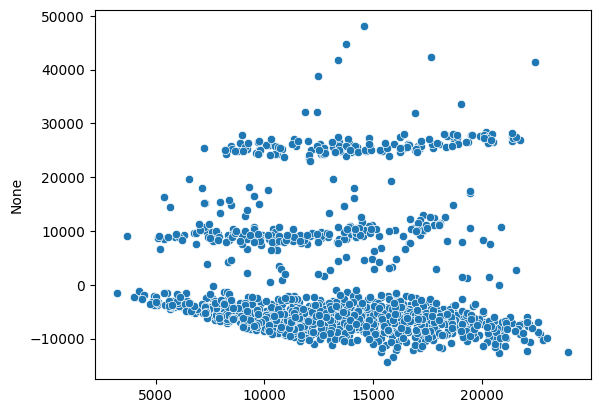

In [11]:
sns.scatterplot(x=model.predict(), y=model.resid)

In [12]:
new_data = pd.DataFrame({
    "age": [0, insurance_df["age"].min(), insurance_df["age"].mean(), insurance_df["age"].max()],
    "bmi": [0, insurance_df["bmi"].min(), insurance_df["bmi"].mean(), insurance_df["bmi"].max()],
})
 
new_data

,age,bmi
0,0.000000,0.000000
1,18.000000,15.960000
2,39.207025,30.663397
3,64.000000,53.130000


In [13]:
X = sm.add_constant(new_data)
 
model.predict(X)

0    -6424.804612
1     3244.072239
2    13270.422265
3    26749.200448
dtype: float64

In [14]:
insurance_df = insurance_df.assign(
    smoker_flag=np.where(insurance_df["smoker"] == "yes", 1, 0),
    female_flag=np.where(insurance_df["sex"] == "female", 1, 0)
)
insurance_df

NameError: name 'np' is not defined

In [15]:
 
X = sm.add_constant(insurance_df[["age", "bmi", "children", "smoker_flag"]])
y = insurance_df["charges"]
 
model = sm.OLS(y, X).fit()
 
model.summary()
 

KeyError: "['smoker_flag'] not in index"

[(-13000.0, 50000.0)]

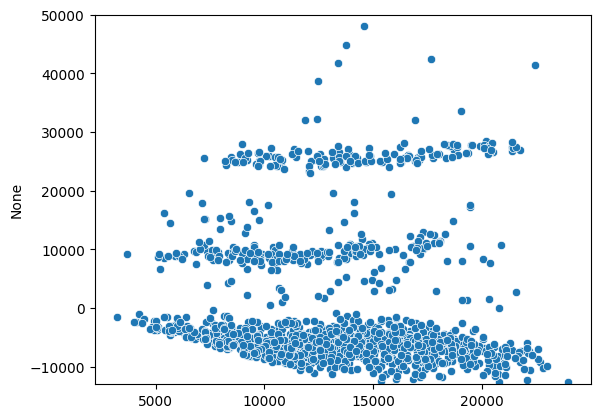

In [16]:
sns.scatterplot(x=model.predict(), y=model.resid).set(ylim=(-13000, 50000) )

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
 
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error
 
np.random.seed(42)
pd.set_option("display.max_columns", 200)

In [19]:
df = sns.load_dataset("tips")
df.tail(10)

,total_bill,tip,sex,smoker,day,time,size
234,15.53,3.00,Male,Yes,Sat,Dinner,2
235,10.07,1.25,Male,No,Sat,Dinner,2
236,12.60,1.00,Male,Yes,Sat,Dinner,2
237,32.83,1.17,Male,Yes,Sat,Dinner,2
238,35.83,4.67,Female,No,Sat,Dinner,3
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [20]:
df.shape, df.isna()

((244, 7),
      total_bill    tip    sex  smoker    day   time   size
 0         False  False  False   False  False  False  False
 1         False  False  False   False  False  False  False
 2         False  False  False   False  False  False  False
 3         False  False  False   False  False  False  False
 4         False  False  False   False  False  False  False
 ..          ...    ...    ...     ...    ...    ...    ...
 239       False  False  False   False  False  False  False
 240       False  False  False   False  False  False  False
 241       False  False  False   False  False  False  False
 242       False  False  False   False  False  False  False
 243       False  False  False   False  False  False  False
 
 [244 rows x 7 columns])

In [21]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
total_bill,244.0,NaN,NaN,NaN,19.785943,8.902412,3.07,13.3475,17.795,24.1275,50.81
tip,244.0,NaN,NaN,NaN,2.998279,1.383638,1.0,2.0,2.9,3.5625,10.0
sex,244,2,Male,157,NaN,NaN,NaN,NaN,NaN,NaN,NaN
smoker,244,2,No,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,244,4,Sat,87,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time,244,2,Dinner,176,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size,244.0,NaN,NaN,NaN,2.569672,0.9511,1.0,2.0,2.0,3.0,6.0


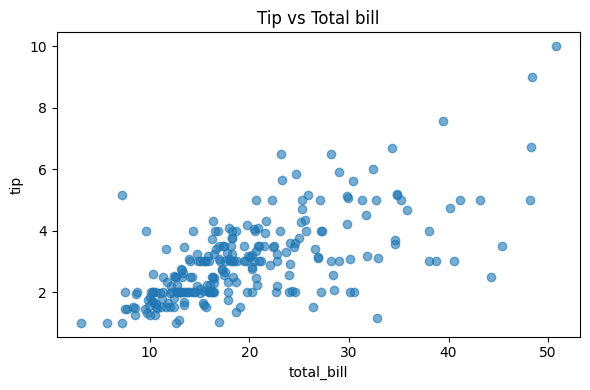

In [22]:
plt.figure(figsize=(6, 4))
plt.scatter(df["total_bill"], df["tip"], alpha=0.6)
plt.title("Tip vs Total bill")
plt.xlabel("total_bill")
plt.ylabel("tip")
plt.tight_layout()
plt.show()

In [23]:
target = "tip"
features_num = ["total_bill", "size"]
features_cat = ["day", "time", "smoker"]
 
# Pats paprasčiausias paruošimas: one-hot su drop_first
X = pd.get_dummies(df[features_num + features_cat], drop_first=True)
y = df[target].copy()
 
X.head()

,total_bill,size,day_Fri,day_Sat,day_Sun,time_Dinner,smoker_No
0,16.99,2,False,False,True,True,True
1,10.34,3,False,False,True,True,True
2,21.01,3,False,False,True,True,True
3,23.68,2,False,False,True,True,True
4,24.59,4,False,False,True,True,True


In [24]:
 
# target
y = df["tip"]
 
# features: skaitiniai + kategoriniai
X_raw = df[["total_bill", "size", "day", "time", "smoker"]]
 
# kategorijų pavertimas į 0/1 stulpelius
X = pd.get_dummies(X_raw, drop_first=True)
 
# (geroji praktika) užtikrinamas skaitinis tipas
X = X.astype(float)
 
# konstanta (interceptas)
X_sm = sm.add_constant(X)
 
model = sm.OLS(y, X_sm).fit()
model.summary()
 

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    tip   R-squared:                       0.470
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     29.89
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           2.15e-29
Time:                        16:02:15   Log-Likelihood:                -347.50
No. Observations:                 244   AIC:                             711.0
Df Residuals:                     236   BIC:                             739.0
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.6103      0.241      2.534      0.012       0.136       1.085
total_bill      0.0943      0.010      9.884      0.000       0.075       0.113
size            0.1764      0.089      1.974      0.050       0.000       0.352
day_Fri         0.1609      0.393      0.410      0.682      -0.612       0.934
day_Sat         0.0351      0.469      0.075      0.940      -0.889       0.959
day_Sun         0.1284      0.469      0.274      0.785      -0.796       1.053
time_Dinner    -0.0681      0.444     -0.154      0.878      -0.942       0.806
smoker_No       0.0865      0.146      0.591      0.555      -0.202       0.375
==============================================================================
Omnibus:                       27.521   Durbin-Watson:                   2.099
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               51.508
Skew:                           0.603   Prob(JB):                     6.53e-12
Kurtosis:                       4.901   Cond. No.                         281.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""